### Step 1 — Basic Data Overview

We inspect the training data shape, data types, and memory usage to understand the structure of the dataset and identify numerical, categorical, date, and ID columns.


In [1]:
import pandas as pd

# Load only the training split
train = pd.read_csv("../artifacts/train.csv")

# Convert date columns to datetime
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for column in date_columns:
    train[column] = pd.to_datetime(train[column], errors="coerce")

# Basic dataset information
print("Shape:", train.shape)

print("\nData types:")
print(train.dtypes)

print("\nMemory usage:")
train.info(memory_usage="deep")

# Display column names
print("\nColumns:")
print(train.columns.tolist())

Shape: (67533, 21)

Data types:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
customer_unique_id                       object
customer_zip_code_prefix                  int64
customer_city                            object
customer_state                           object
item_count                              float64
total_price                             float64
total_freight                           float64
unique_products                         float64
unique_sellers                          float64
payment_total                           float64
payment_count                           float64
late                                      int64
order_ye

### Step 2 — Missing Values

We check missing values in the training data to identify where they occur and whether the missing information may be meaningful.


In [2]:
# Check missing values

missing_values = train.isnull().sum()

missing_summary = pd.DataFrame(
    {
        "missing_count": missing_values,
        "missing_percentage": (missing_values / len(train) * 100).round(2),
    }
)

# Show only columns with missing values
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values(
    "missing_count", ascending=False
)

missing_summary

,missing_count,missing_percentage
order_approved_at,14,0.02
order_delivered_carrier_date,1,0.00
payment_total,1,0.00
payment_count,1,0.00


### Step 2.1 — Inspect Missing Values

We inspect the orders with missing values to understand whether the missing information is meaningful or simply due to incomplete records.


In [3]:
# Inspect rows with missing values

missing_rows = train[
    train[
        [
            "order_approved_at",
            "order_delivered_carrier_date",
            "payment_total",
            "payment_count",
        ]
    ]
    .isna()
    .any(axis=1)
]

missing_rows[
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "payment_total",
        "payment_count",
        "late",
    ]
]

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,payment_total,payment_count,late
0,bfbd0f9bdef84302105ad712db648a6c,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,NaN,NaN,1
477,c1d4211b3dae76144deccd6c74144a88,delivered,2017-01-19 12:48:08,NaT,2017-01-25 14:56:50,54.51,1.0,0
495,7002a78c79c519ac54022d4f8a65e6e8,delivered,2017-01-19 22:26:59,NaT,2017-01-27 11:08:05,60.42,1.0,0
2118,12a95a3c06dbaec84bcfb0e2da5d228a,delivered,2017-02-17 13:05:55,NaT,2017-02-22 11:23:11,95.76,1.0,0
2125,3c0b8706b065f9919d0505d3b3343881,delivered,2017-02-17 15:53:27,NaT,2017-02-22 11:31:30,157.19,1.0,0
2130,2eecb0d85f281280f79fa00f9cec1a95,delivered,2017-02-17 17:21:55,NaT,2017-02-22 11:42:51,154.23,1.0,0
2148,d77031d6a3c8a52f019764e68f211c69,delivered,2017-02-18 11:04:19,NaT,2017-02-23 07:23:36,39.95,1.0,0
2155,8a9adc69528e1001fc68dd0aaebbb54a,delivered,2017-02-18 12:45:31,NaT,2017-02-23 09:01:52,396.86,1.0,0
2157,7013bcfc1c97fe719a7b5e05e61c12db,delivered,2017-02-18 13:29:47,NaT,2017-02-22 16:25:25,65.52,1.0,0
2166,e04abd8149ef81b95221e88f6ed9ab6a,delivered,2017-02-18 14:40:00,NaT,2017-02-23 12:04:47,349.01,1.0,0


### Missing Values Finding

Missing values are very limited. Most occur in `order_approved_at` (14 rows), while only one row is missing carrier delivery and payment information. Since the missing rate is extremely low, these values will be handled later during feature engineering if needed.


### Step 3 — Numerical Analysis

We examine the numerical features using summary statistics, ranges, and skewness to identify unusual values and potential outliers.


In [4]:
# Select numerical columns

numerical_columns = [
    "customer_zip_code_prefix",
    "item_count",
    "total_price",
    "total_freight",
    "unique_products",
    "unique_sellers",
    "payment_total",
    "payment_count",
]

# Summary statistics
numerical_summary = train[numerical_columns].describe().T

# Add skewness
numerical_summary["skewness"] = train[numerical_columns].skew()

# Display results
numerical_summary[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max", "skewness"]
].round(2)

,count,mean,std,min,25%,50%,75%,max,skewness
customer_zip_code_prefix,67533.0,36010.13,29908.27,1004.00,12061.00,25959.00,60360.00,99980.00,0.74
item_count,67533.0,1.14,0.54,1.00,1.00,1.00,1.00,21.00,8.11
total_price,67533.0,135.88,205.19,2.29,45.90,85.00,149.90,13440.00,10.72
total_freight,67533.0,22.24,20.00,0.00,14.10,16.79,23.70,1002.29,8.58
unique_products,67533.0,1.04,0.22,1.00,1.00,1.00,1.00,7.00,7.68
unique_sellers,67533.0,1.01,0.11,1.00,1.00,1.00,1.00,5.00,10.53
payment_total,67532.0,158.17,214.28,10.07,61.63,104.19,175.48,13664.08,10.15
payment_count,67532.0,1.05,0.40,1.00,1.00,1.00,1.00,26.00,22.42


### Numerical Analysis Finding

Most numerical features are strongly right-skewed, especially price, freight, payment values, and payment count. This indicates the presence of high-value orders and a small number of extreme observations. These values will be considered during feature engineering rather than removed automatically.


### Step 4 — Numerical Distributions

We visualize the numerical features to better understand their distributions and identify highly skewed or extreme values.


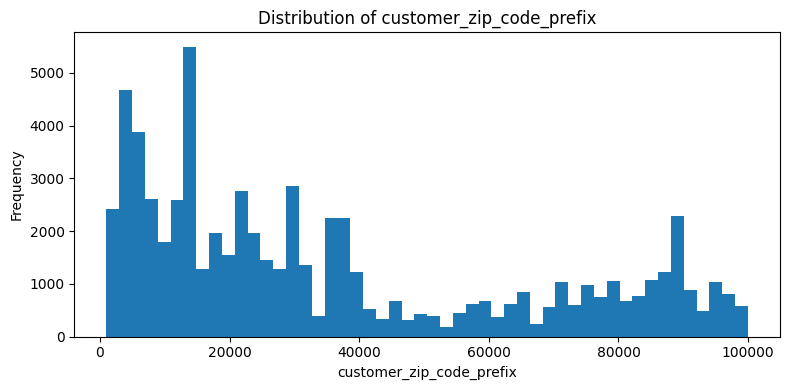

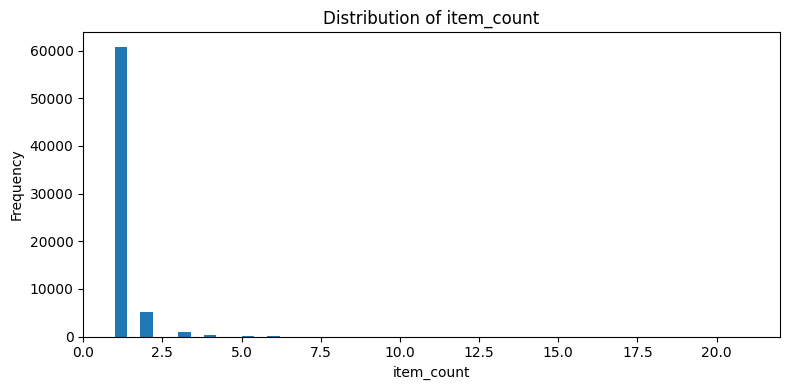

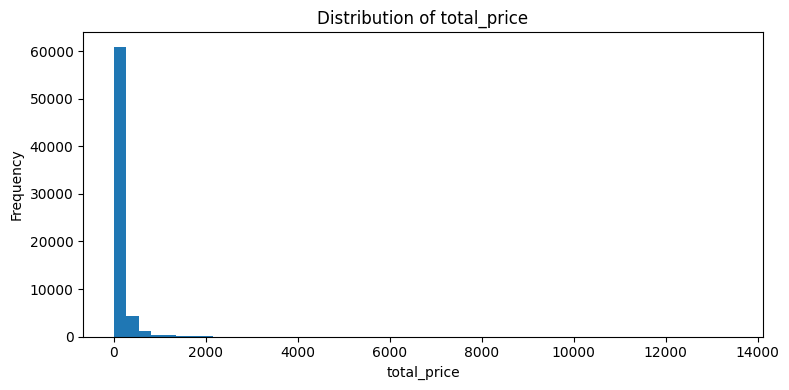

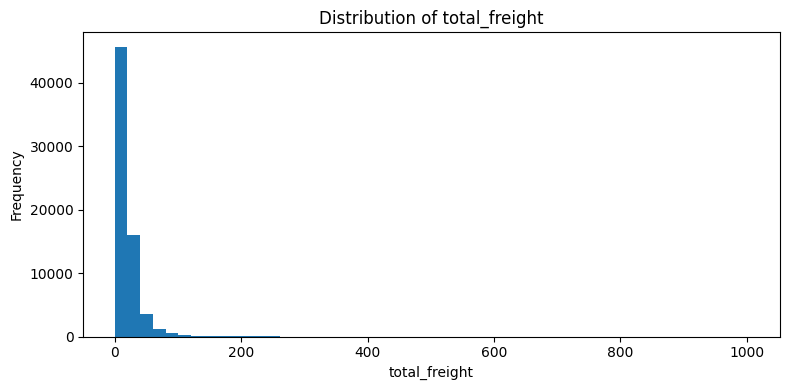

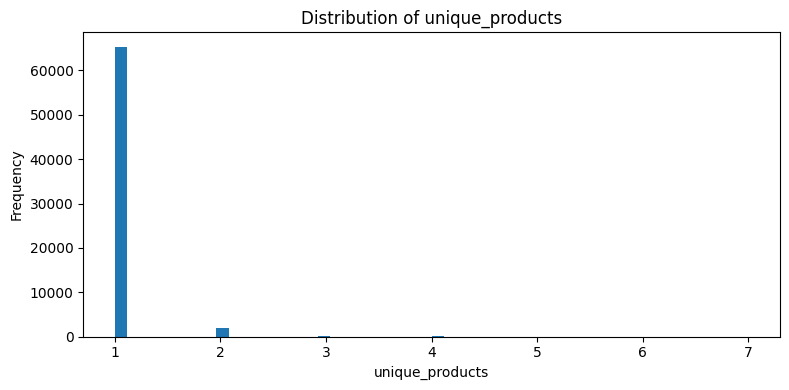

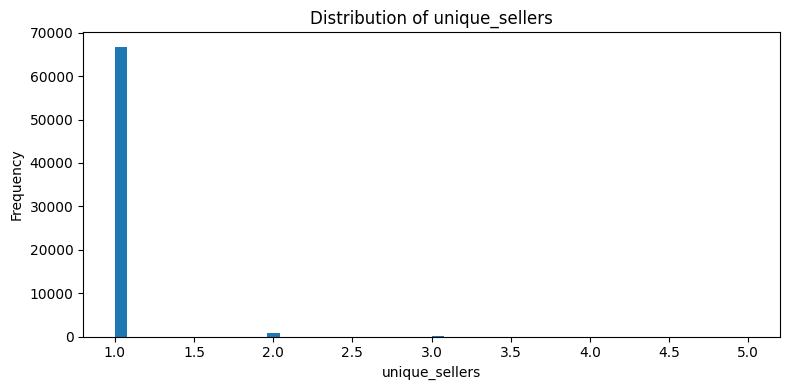

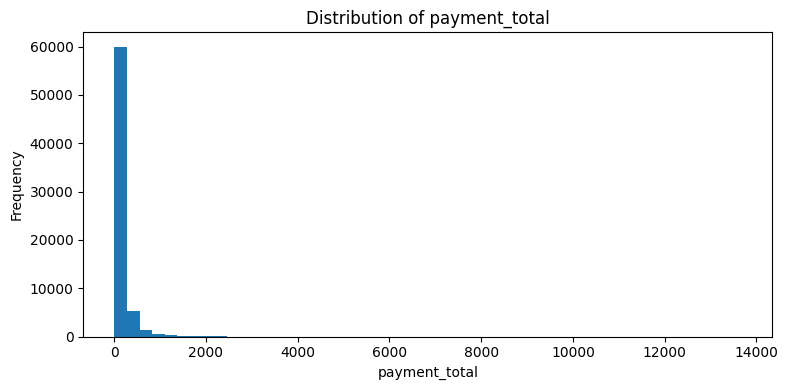

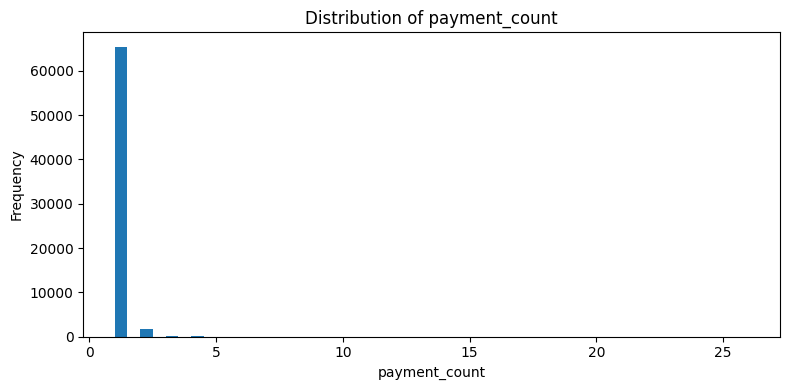

In [5]:
import matplotlib.pyplot as plt

# Plot distributions of numerical features

for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    plt.hist(train[column].dropna(), bins=50)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

### Step 5 — Categorical Analysis

We examine categorical features using value counts and cardinality to identify common, rare, or inconsistent categories.


In [6]:
# Select categorical columns

categorical_columns = ["order_status", "customer_city", "customer_state"]

# Check cardinality and most common values

for column in categorical_columns:
    print(f"\n{'=' * 50}")
    print(f"Column: {column}")
    print(f"Unique values: {train[column].nunique()}")
    print("\nTop values:")
    print(train[column].value_counts().head(10))


Column: order_status
Unique values: 2

Top values:
order_status
delivered    67527
canceled         6
Name: count, dtype: int64

Column: customer_city
Unique values: 3747

Top values:
customer_city
sao paulo                9921
rio de janeiro           4780
belo horizonte           1869
brasilia                 1395
curitiba                 1020
porto alegre              975
campinas                  967
salvador                  823
guarulhos                 724
sao bernardo do campo     622
Name: count, dtype: int64

Column: customer_state
Unique values: 27

Top values:
customer_state
SP    27204
RJ     8967
MG     8130
RS     3912
PR     3461
SC     2577
BA     2307
ES     1445
GO     1409
DF     1404
Name: count, dtype: int64


### Categorical Analysis Finding

`order_status` is highly imbalanced because almost all training orders are delivered. `customer_city` has high cardinality with 3,747 unique cities, while `customer_state` has only 27 categories and is more suitable for categorical encoding. No obvious inconsistent categories were found.


### Step 5.1 — Rare and Messy Categories

We check categorical values for rare categories and inconsistent formatting before selecting encoding methods.


In [11]:
# Check rare categories and inconsistent formatting

for column in categorical_columns:
    print(f"\n{'=' * 50}")
    print(f"Column: {column}")

    # Count rare categories
    value_counts = train[column].value_counts(dropna=False)

    rare_categories = value_counts[value_counts <= 5]

    print("Number of rare categories (5 or fewer orders):", len(rare_categories))

    # Check for leading/trailing spaces
    string_values = train[column].dropna().astype(str)

    spaces = string_values[string_values.str.strip() != string_values]

    print("Values with leading/trailing spaces:", len(spaces))

    # Check duplicated category values
    print("Unique values:", train[column].nunique())


Column: order_status
Number of rare categories (5 or fewer orders): 0
Values with leading/trailing spaces: 0
Unique values: 2

Column: customer_city
Number of rare categories (5 or fewer orders): 2630
Values with leading/trailing spaces: 0
Unique values: 3747

Column: customer_state
Number of rare categories (5 or fewer orders): 0
Values with leading/trailing spaces: 0
Unique values: 27


### Rare and Messy Categories Finding

`customer_city` has high cardinality with 3,747 unique cities, including many rare categories. No leading or trailing spaces were detected. `customer_state` and `order_status` have relatively few categories and no significant rare-category issue.


### Step 6 — Feature Relations with the Label

We compare selected numerical features across late and on-time orders to identify variables that may help predict delivery delays.


In [7]:
# Compare numerical features by the late-delivery label

relation_summary = train.groupby("late")[numerical_columns].mean().T

relation_summary.columns = ["On-time (0)", "Late (1)"]

relation_summary.round(2)

,On-time (0),Late (1)
customer_zip_code_prefix,35629.39,39846.63
item_count,1.14,1.11
total_price,134.51,149.77
total_freight,21.95,25.20
unique_products,1.04,1.02
unique_sellers,1.01,1.00
payment_total,156.50,175.01
payment_count,1.05,1.04


### Step 6.1 — Correlation with the Label

We calculate the correlation between numerical features and the late-delivery label to identify potentially useful features.


In [8]:
# Calculate correlations with the target

correlation_with_late = (
    train[numerical_columns + ["late"]]
    .corr()["late"]
    .drop("late")
    .sort_values(ascending=False)
)

correlation_with_late.round(3)

total_freight               0.047
customer_zip_code_prefix    0.040
payment_total               0.025
total_price                 0.021
payment_count              -0.006
item_count                 -0.016
unique_products            -0.022
unique_sellers             -0.026
Name: late, dtype: float64

### Correlation Finding

All numerical features show weak linear correlation with the `late` label. `total_freight` has the highest correlation (0.047), but the relationship is still very weak. Therefore, the features should not be selected or removed based on correlation alone.


### Step 6.2 — Outliers and Cross-tab Analysis

We check numerical outliers and compare categorical features with the late-delivery label to identify unusual values and useful relationships.


In [12]:
# Check potential outliers using the IQR method

outlier_summary = []

for column in numerical_columns:
    q1 = train[column].quantile(0.25)
    q3 = train[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = ((train[column] < lower_bound) | (train[column] > upper_bound)).sum()

    outlier_summary.append(
        {
            "feature": column,
            "lower_bound": round(lower_bound, 2),
            "upper_bound": round(upper_bound, 2),
            "outlier_count": outliers,
            "outlier_percentage": round(outliers / len(train) * 100, 2),
        }
    )

outlier_summary = pd.DataFrame(outlier_summary)

print("Potential outliers:")
print(outlier_summary)


# Cross-tabulation of categorical features against the label

print("\nLate delivery by order status:")
print(pd.crosstab(train["order_status"], train["late"], normalize="index").round(3))

print("\nLate delivery by customer state:")
print(pd.crosstab(train["customer_state"], train["late"], normalize="index").round(3))

Potential outliers:
                    feature  lower_bound  upper_bound  outlier_count  \
0  customer_zip_code_prefix    -60387.50    132808.50              0   
1                item_count         1.00         1.00           6759   
2               total_price      -110.10       305.90           5361   
3             total_freight        -0.30        38.10           6629   
4           unique_products         1.00         1.00           2210   
5            unique_sellers         1.00         1.00            776   
6             payment_total      -109.15       346.27           5308   
7             payment_count         1.00         1.00           2129   

   outlier_percentage  
0                0.00  
1               10.01  
2                7.94  
3                9.82  
4                3.27  
5                1.15  
6                7.86  
7                3.15  

Late delivery by order status:
late              0      1
order_status              
canceled      0.833  0.167
de

### Outliers and Cross-tab Finding

Several numerical features contain statistical outliers, especially item count, price, freight, and payment values. These observations may represent valid orders and will not be removed automatically. Late-delivery rates also vary across customer states, suggesting that geographic information may provide useful predictive information.


### Step 7 — Date Analysis

We analyze purchase dates, delivery duration, months, and weekdays to identify possible patterns related to late delivery.


Delivery duration summary:
count    67533.00
mean        13.82
std         10.25
min          0.53
25%          7.45
50%         11.48
75%         17.19
max        209.63
Name: delivery_days, dtype: float64

Late rate by month:
    purchase_month  total_orders  late_orders  late_rate
0                1          7819          487       6.23
1                2          8209         1102      13.42
2                3          9549         1638      17.15
3                4          5510          387       7.02
4                5          3545          128       3.61
5                6          3135          121       3.86
6                7          3872          133       3.43
7                8          4193          139       3.32
8                9          4151          217       5.23
9               10          4748          240       5.05
10              11          7288         1043      14.31
11              12          5514          462       8.38

Late rate by weekday:
  purcha

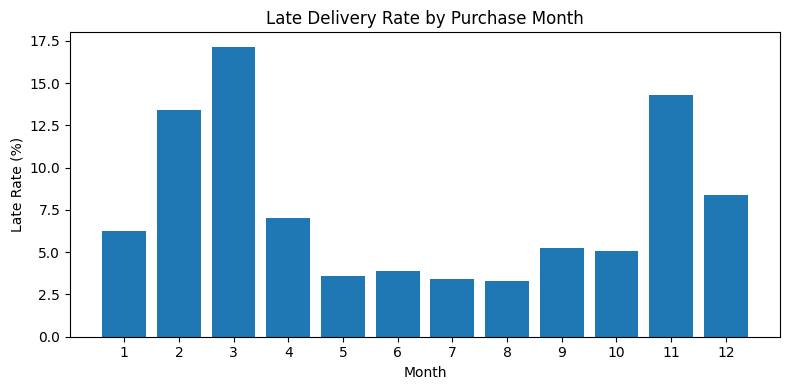

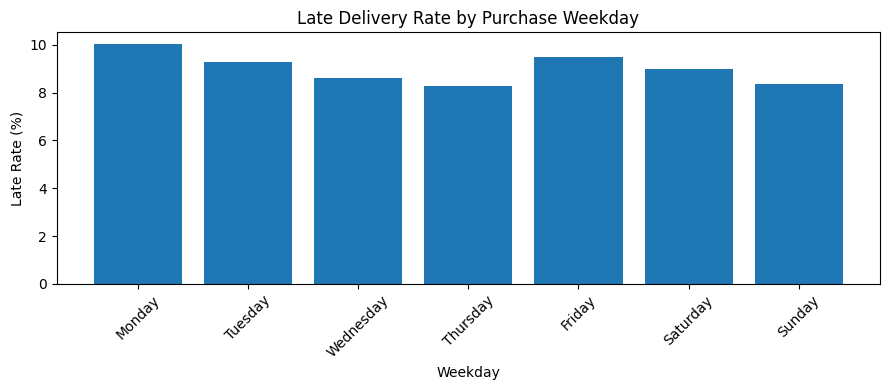

In [13]:
import matplotlib.pyplot as plt

# Create date-based variables for EDA
train["purchase_month"] = train["order_purchase_timestamp"].dt.month
train["purchase_weekday"] = train["order_purchase_timestamp"].dt.day_name()

train["delivery_days"] = (
    train["order_delivered_customer_date"] - train["order_purchase_timestamp"]
).dt.total_seconds() / 86400

# Late rate by month
monthly_late = (
    train.groupby("purchase_month")["late"]
    .agg(total_orders="count", late_orders="sum", late_rate="mean")
    .reset_index()
)

monthly_late["late_rate"] = (monthly_late["late_rate"] * 100).round(2)

# Late rate by weekday
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

weekday_late = (
    train.groupby("purchase_weekday")["late"]
    .agg(total_orders="count", late_orders="sum", late_rate="mean")
    .reindex(weekday_order)
    .reset_index()
)

weekday_late["late_rate"] = (weekday_late["late_rate"] * 100).round(2)

print("Delivery duration summary:")
print(train["delivery_days"].describe().round(2))

print("\nLate rate by month:")
print(monthly_late)

print("\nLate rate by weekday:")
print(weekday_late)

# Monthly late-rate chart
plt.figure(figsize=(8, 4))
plt.bar(monthly_late["purchase_month"], monthly_late["late_rate"])
plt.title("Late Delivery Rate by Purchase Month")
plt.xlabel("Month")
plt.ylabel("Late Rate (%)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

# Weekday late-rate chart
plt.figure(figsize=(9, 4))
plt.bar(weekday_late["purchase_weekday"], weekday_late["late_rate"])
plt.title("Late Delivery Rate by Purchase Weekday")
plt.xlabel("Weekday")
plt.ylabel("Late Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Date Analysis Finding

Delivery duration varies considerably, with an average of 13.82 days and some extreme values. Late-delivery rates also vary across purchase months, with higher rates in February, March, and November. This suggests that time-based features may help capture seasonal delivery patterns.


### Step 7.1 — Holiday Effect

We check whether orders purchased on Brazilian holidays have a different late-delivery rate from regular days.


In [15]:
# Check holiday effect

try:
    import holidays

    # Create Brazilian holiday calendar for the years in the training data
    years = train["order_purchase_timestamp"].dt.year.unique()
    brazil_holidays = holidays.Brazil(years=years)

    # Mark whether the purchase date was a Brazilian holiday
    train["is_holiday"] = train["order_purchase_timestamp"].dt.date.isin(
        brazil_holidays
    )

    holiday_late = (
        train.groupby("is_holiday")["late"]
        .agg(total_orders="count", late_orders="sum", late_rate="mean")
        .reset_index()
    )

    holiday_late["late_rate"] = (holiday_late["late_rate"] * 100).round(2)

    print("Late-delivery rate by holiday status:")
    print(holiday_late)

except ImportError:
    print("The 'holidays' package is not installed. Holiday analysis will be skipped.")

Late-delivery rate by holiday status:
   is_holiday  total_orders  late_orders  late_rate
0       False         66462         6023       9.06
1        True          1071           74       6.91


### Holiday Effect Finding

Orders placed on holidays had a lower late-delivery rate (6.91%) compared with orders placed on non-holidays (9.06%). However, the number of holiday orders is much smaller, so this difference should be interpreted cautiously. The `is_holiday` feature may still be considered during feature engineering.


### Step 8 — Geographic Analysis

We examine customer states and ZIP-code prefixes to identify geographic patterns related to late delivery.


Late-delivery rate by customer state:
   customer_state  total_orders  late_orders  late_rate
1              AL           298           83      27.85
9              MA           548          118      21.53
5              CE           948          173      18.25
21             RR            29            5      17.24
24             SE           246           42      17.07
16             PI           348           58      16.67
18             RJ          8967         1487      16.58
4              BA          2307          346      15.00
13             PA           718           96      13.37
7              ES          1445          192      13.29
26             TO           197           26      13.20
14             PB           370           47      12.70
19             RN           349           43      12.32
23             SC          2577          308      11.95
15             PE          1117          133      11.91
11             MS           502           59      11.75
8         

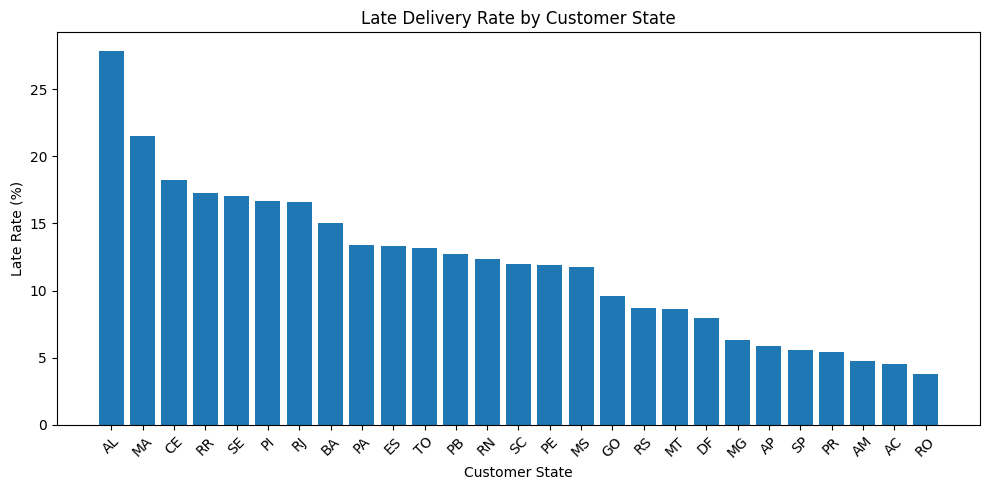

In [10]:
# Late-delivery rate by customer state

state_late = (
    train.groupby("customer_state")["late"]
    .agg(total_orders="count", late_orders="sum", late_rate="mean")
    .reset_index()
)

state_late["late_rate"] = (state_late["late_rate"] * 100).round(2)

state_late = state_late.sort_values("late_rate", ascending=False)

print("Late-delivery rate by customer state:")
print(state_late)

# Geographic distribution
print("\nNumber of customer states:", train["customer_state"].nunique())
print("Number of ZIP-code prefixes:", train["customer_zip_code_prefix"].nunique())

# Plot late rate by state
plt.figure(figsize=(10, 5))
plt.bar(state_late["customer_state"], state_late["late_rate"])
plt.title("Late Delivery Rate by Customer State")
plt.xlabel("Customer State")
plt.ylabel("Late Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Geographic Analysis Finding

Late-delivery rates vary across customer states. Some states show noticeably higher late rates, while larger states such as SP have lower rates. However, states with very few orders may have less reliable rates. Customer state can therefore be considered as a potential categorical feature.


### Step 9 — Save EDA Charts

The main EDA charts are saved as image files so they can be included as project artifacts and reviewed later.


In [16]:
import os
import matplotlib.pyplot as plt

# Create directory for EDA charts
charts_dir = "../artifacts/eda_charts"
os.makedirs(charts_dir, exist_ok=True)

# 1. Numerical distributions
for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    plt.hist(train[column].dropna(), bins=30)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()

    plt.savefig(
        os.path.join(charts_dir, f"{column}_distribution.png"),
        dpi=150,
        bbox_inches="tight",
    )
    plt.close()

# 2. Late rate by purchase month
plt.figure(figsize=(8, 4))
plt.bar(monthly_late["purchase_month"], monthly_late["late_rate"])
plt.title("Late Delivery Rate by Purchase Month")
plt.xlabel("Month")
plt.ylabel("Late Rate (%)")
plt.xticks(range(1, 13))
plt.tight_layout()

plt.savefig(
    os.path.join(charts_dir, "late_rate_by_month.png"), dpi=150, bbox_inches="tight"
)
plt.close()

# 3. Late rate by weekday
plt.figure(figsize=(9, 4))
plt.bar(weekday_late["purchase_weekday"], weekday_late["late_rate"])
plt.title("Late Delivery Rate by Purchase Weekday")
plt.xlabel("Weekday")
plt.ylabel("Late Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    os.path.join(charts_dir, "late_rate_by_weekday.png"), dpi=150, bbox_inches="tight"
)
plt.close()

# 4. Late rate by customer state
plt.figure(figsize=(10, 5))
plt.bar(state_late["customer_state"], state_late["late_rate"])
plt.title("Late Delivery Rate by Customer State")
plt.xlabel("Customer State")
plt.ylabel("Late Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    os.path.join(charts_dir, "late_rate_by_customer_state.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.close()

print("EDA charts saved successfully.")
print("Location:", charts_dir)
print("Number of charts:", len(os.listdir(charts_dir)))

EDA charts saved successfully.
Location: ../artifacts/eda_charts
Number of charts: 11


### *Step 10 — Final EDA Findings Summary*

The EDA was performed using the training split only. The main findings are summarized below:

* The dataset contains 67,533 training orders, with a strongly imbalanced target: most orders are on time and a smaller portion are late.

* Missing values are very limited and mainly occur in order approval, carrier delivery date, and aggregated payment features.

* Numerical features such as price, freight, payment amount, and item count are strongly right-skewed and contain statistical outliers. These values were not removed automatically because they may represent valid orders.

* Customer city has high cardinality and many rare categories, while customer state has only 27 categories and is more suitable as a categorical feature.

* Numerical features show weak linear correlations with the late-delivery label, so correlation alone was not used for feature selection.

* Late-delivery rates vary across customer states, suggesting that geographic information may be useful for prediction.

* Delivery duration varies considerably, and late-delivery rates differ across purchase months, with higher rates in February, March, and November.

* Orders placed on holidays had a slightly lower late-delivery rate than orders placed on non-holidays, but holiday orders are much fewer, so this difference should be interpreted cautiously.

* The analysis suggests that temporal, geographic, order-value, item-count, payment, and categorical features may be useful candidates for the next feature-engineering stage.

These findings will guide feature selection and preprocessing in the next notebook.


In [17]:
findings = """
EDA Findings Summary

1. The training dataset contains 67,533 orders and the target variable is imbalanced, with most orders being on time and a smaller portion being late.

2. Missing values are very limited and mainly occur in order approval, carrier delivery date, and aggregated payment features.

3. Numerical features such as price, freight, payment amount, and item count are strongly right-skewed and contain statistical outliers. These values were not removed automatically because they may represent valid orders.

4. Customer city has high cardinality and many rare categories, while customer state has only 27 categories and is more suitable as a categorical feature.

5. Numerical features show weak linear correlations with the late-delivery label, so correlation alone was not used for feature selection.

6. Late-delivery rates vary across customer states, suggesting that geographic information may be useful for prediction.

7. Delivery duration varies considerably, and late-delivery rates differ across purchase months, with higher rates in February, March, and November.

8. Orders placed on holidays had a slightly lower late-delivery rate than orders placed on non-holidays. However, holiday orders are much fewer, so this difference should be interpreted cautiously.

9. Temporal, geographic, order-value, item-count, payment, and categorical features may be useful candidates for feature engineering.

These findings will guide feature selection and preprocessing in the next notebook.
"""

findings_path = "../artifacts/eda_findings.txt"

with open(findings_path, "w", encoding="utf-8") as f:
    f.write(findings.strip())

print("EDA findings summary saved successfully.")
print("Location:", findings_path)

EDA findings summary saved successfully.
Location: ../artifacts/eda_findings.txt
